In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
sns.set_palette('rainbow')
plt.rcParams['figure.figsize']=(10,5)

In [2]:
df=pd.read_csv("german_credit_data_updated.csv")

In [3]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose',
       'Credit Risk'],
      dtype='str')

In [4]:
df.shape

(954, 11)

In [5]:
df.isnull()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Credit Risk
0,False,False,False,False,False,True,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,True,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
949,False,False,False,False,False,False,True,False,False,False,False
950,False,False,False,False,False,False,False,False,False,False,False
951,False,False,False,False,False,False,False,False,False,False,False
952,False,False,False,False,False,False,False,False,False,False,False


In [6]:
df.isnull().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     175
Checking account    378
Credit amount         0
Duration              0
Purpose               0
Credit Risk           0
dtype: int64

In [7]:
selected_cols=["Age","Credit amount","Duration"]
cluster_data=df.loc[:,selected_cols]

In [8]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

# 3D Plot
def _3d_data_plot(data, labels=None):
    fig = plt.figure(figsize=(15, 10))
    ax = fig.add_subplot(111, projection='3d')

    scatter = ax.scatter(
        data["Credit amount"],
        data["Duration"],
        data["Age"],
        c=labels if labels is not None else 'black',
        cmap='rainbow'
    )

    ax.set_xlabel("Credit amount")
    ax.set_ylabel("Duration")
    ax.set_zlabel("Age")

    if labels is not None:
        plt.colorbar(scatter)

    plt.tight_layout()
    plt.show()


# 2D Scatter Plot
def scatter_plot(data, hue=None):
    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        x="Credit amount",
        y="Duration",
        data=data,
        hue=hue,
        palette="rainbow"
    )

    plt.xlabel("Credit amount")
    plt.ylabel("Duration")
    plt.title("Credit amount vs Duration")
    plt.tight_layout()
    plt.show()
def box_plot(df):
    fig,ax = plt.subplots(1,3,figsize=(20,5))
    sns.boxplot(df['Credit amount'],ax= ax[0])
    sns.boxplot(df['Duration'],ax= ax[1])
    sns.boxplot(df['Age'],ax= ax[2])
    plt.tight_layout()

def distribution_plot(df):
    fig,ax = plt.subplots(1,3,figsize=(20,5))
    sns.histplot(df["Age"],ax=ax[0])
    sns.histplot(df["Credit amount"],ax=ax[1])
    sns.histplot(df["Duration"],ax=ax[2])
    plt.tight_layout()
   

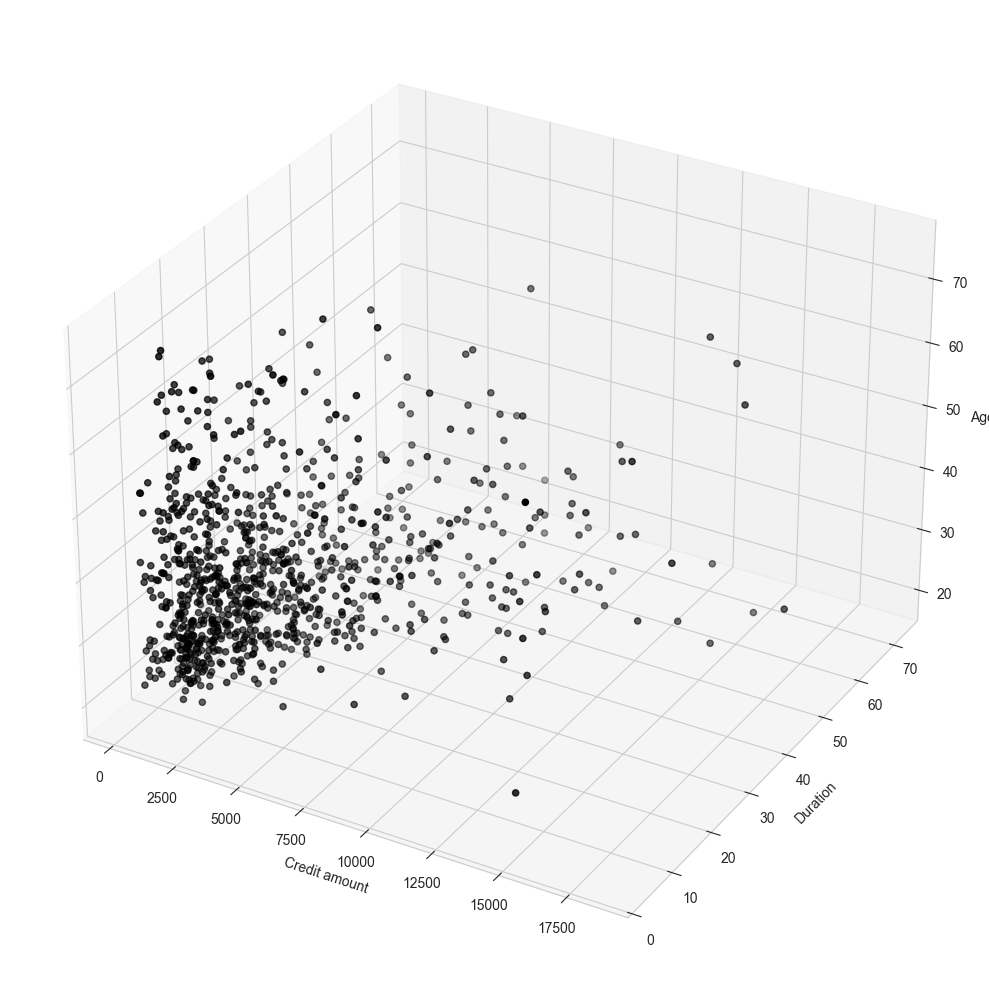

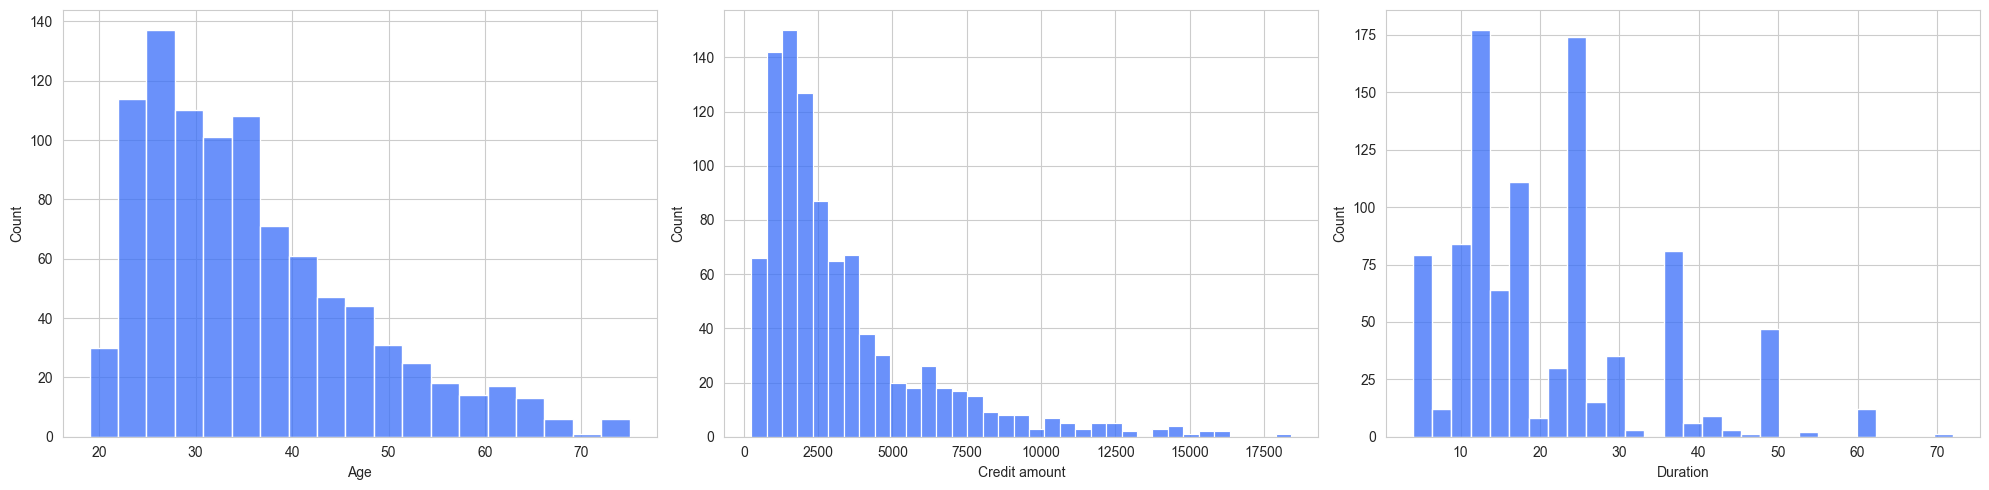

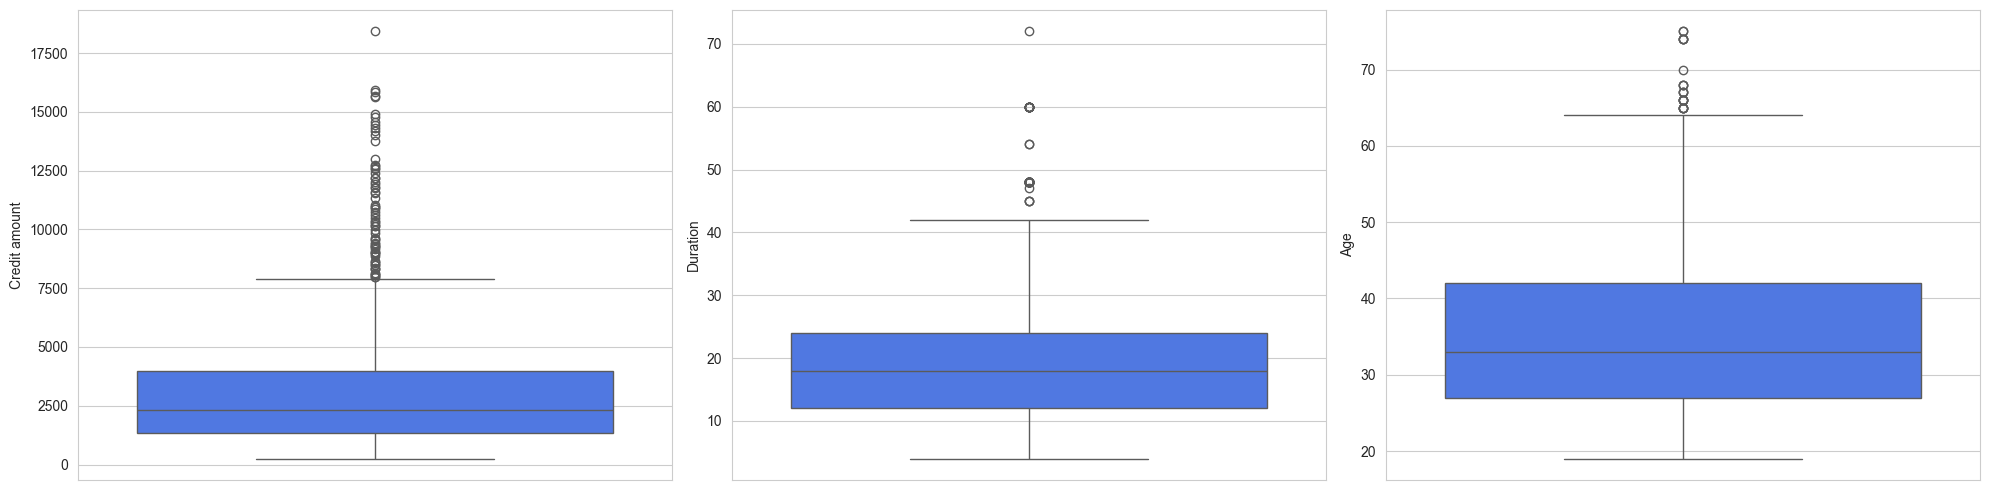

In [9]:
#plot data
_3d_data_plot(cluster_data)
distribution_plot(cluster_data)
box_plot(cluster_data)

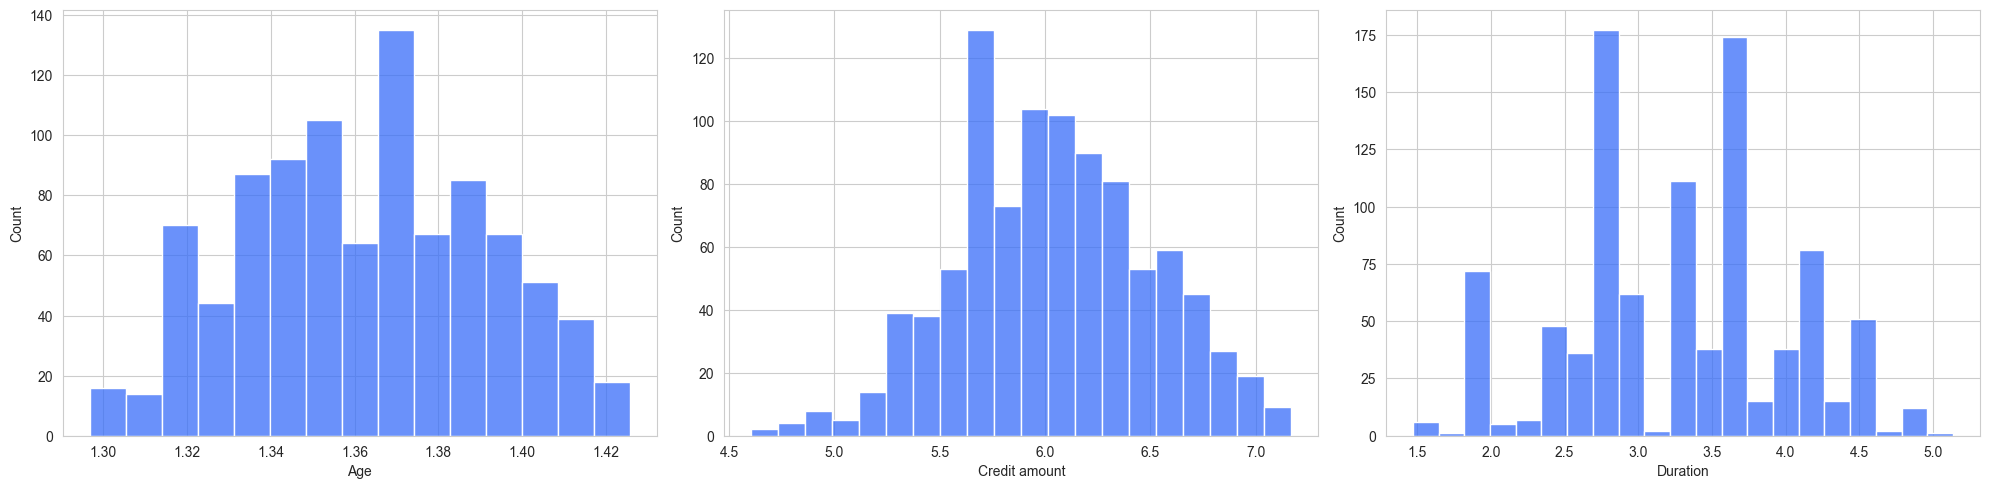

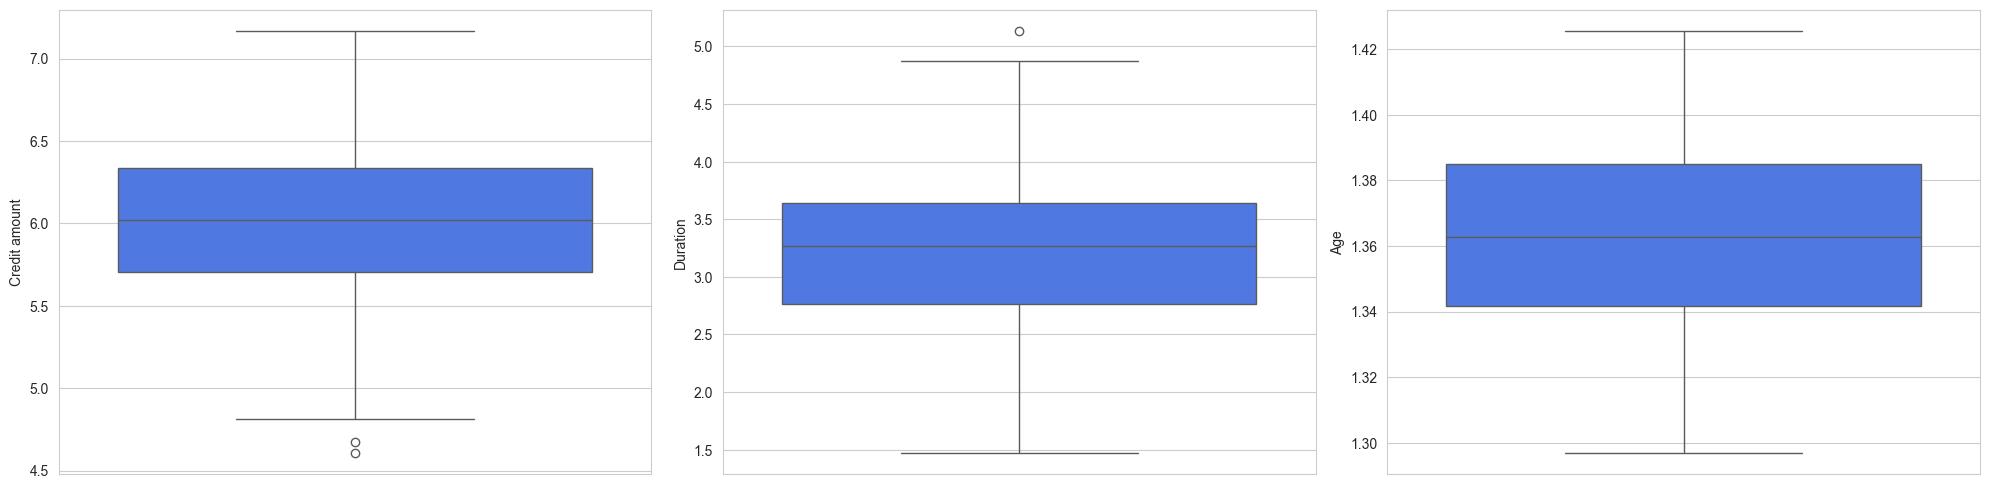

In [10]:
skew_fix_data=None
from scipy.stats import boxcox
skew_fix_data = pd.DataFrame()
for col in selected_cols:
    skew_fix_data[col], _ = boxcox(cluster_data[col])  # Adding 1 to avoid log(0)
distribution_plot(skew_fix_data)
box_plot(skew_fix_data)

In [11]:
from sklearn.preprocessing import StandardScaler

In [12]:
scalar = None
scalar_data = None
scalar=StandardScaler()
scaled_data = scalar.fit_transform(skew_fix_data)

In [13]:
scaled_data.mean(),scaled_data.var()

(np.float64(-1.6137413635362163e-16), np.float64(1.0))

In [14]:
from sklearn.cluster import KMeans

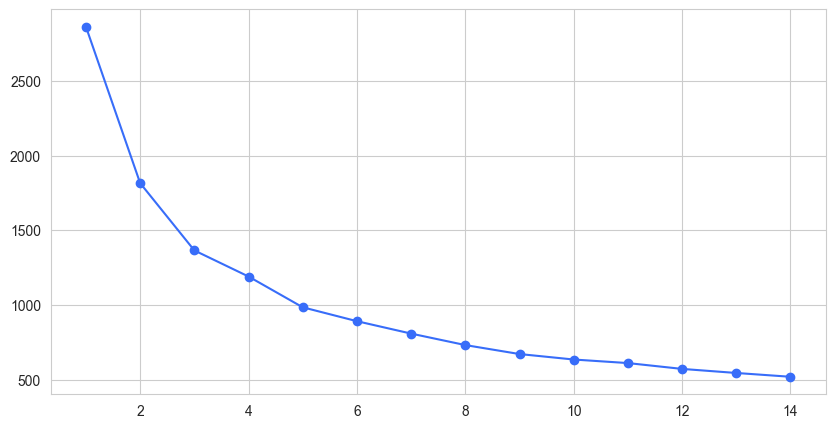

In [15]:
cluster_range = None,
inertias =[]
kmeans= None
cluster_range = np.arange(1, 15)
for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertias.append(kmeans.inertia_)
plt.plot(cluster_range, inertias, marker='o')
plt.show()


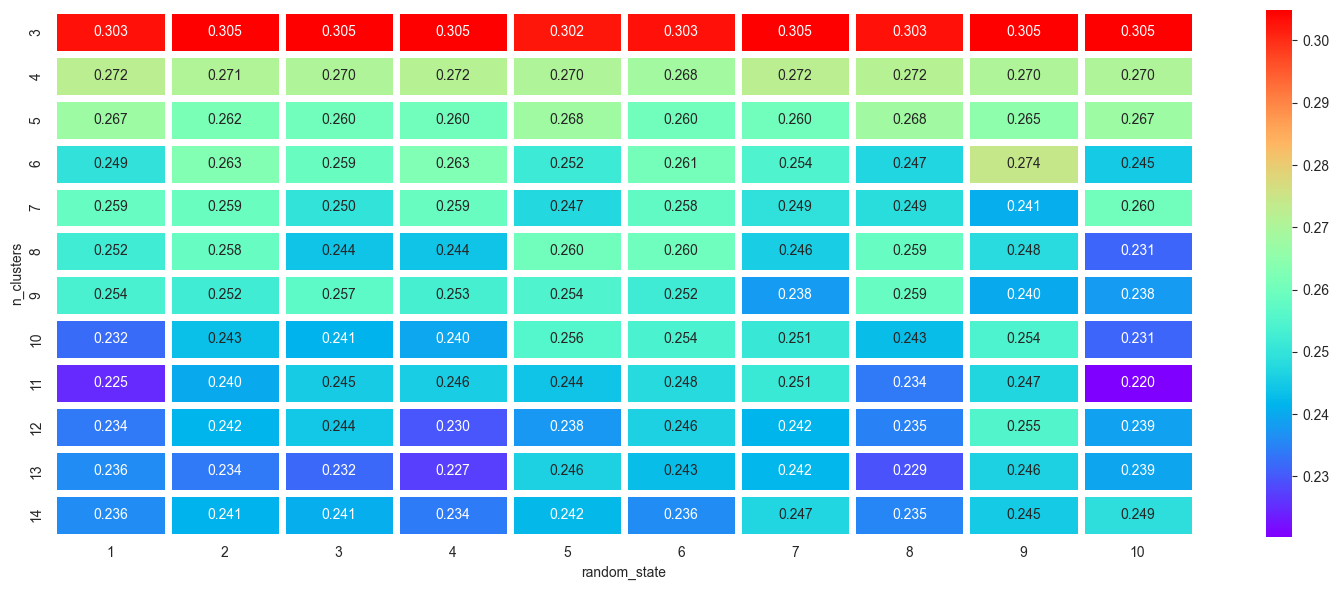

In [16]:
from sklearn.metrics import silhouette_score
cluster_range = None
random_range=None
results = []
cluster_range = [i for i in range(3, 15)]
random_range = [i for i in range(1, 11)]

for k in cluster_range:
    for random_state in random_range:
        kmeans = KMeans(n_clusters=k, random_state=random_state)
        labels = kmeans.fit_predict(scaled_data)
        score = silhouette_score(scaled_data, labels)
        results.append((k, random_state, score))
result = pd.DataFrame(results, columns=['n_clusters', 'random_state', 'silhouette_score'])
pivot_km = pd.pivot_table(result, values='silhouette_score', index='n_clusters', columns='random_state')
#plot tables
plt.figure(figsize=(15, 6))
sns.heatmap(pivot_km,annot= True,linewidths=5,fmt='.3f',cmap='rainbow')
plt.tight_layout()
plt.show()

In [17]:
final_kmeans = None
labels = None
final_kmeans = KMeans(n_clusters=3, random_state=1)
final_kmeans.fit(scaled_data)
labels = final_kmeans.predict(scaled_data)
clustered_data= cluster_data.assign(Cluster = labels)

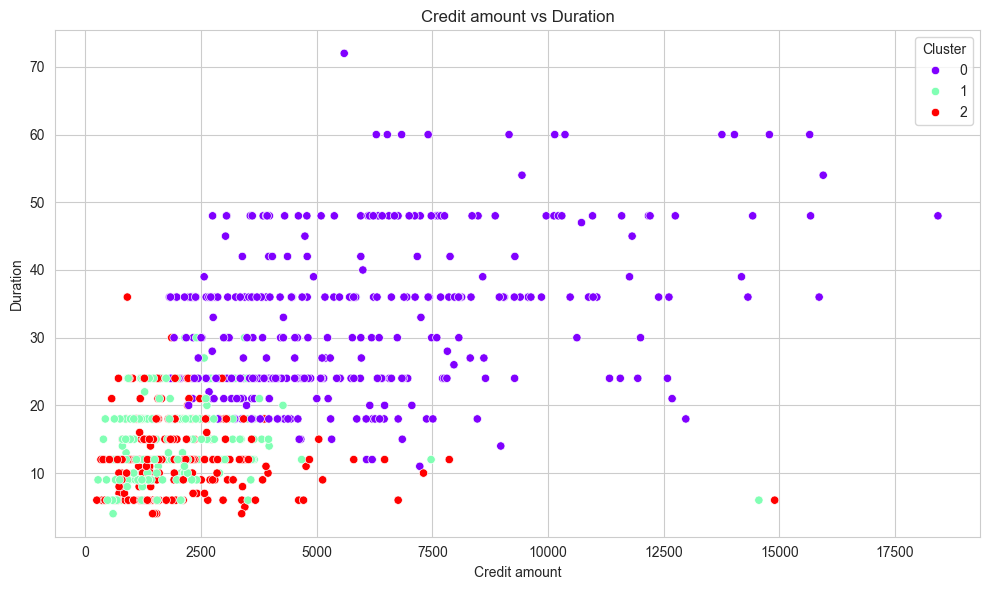

In [18]:
scatter_plot(clustered_data,"Cluster")

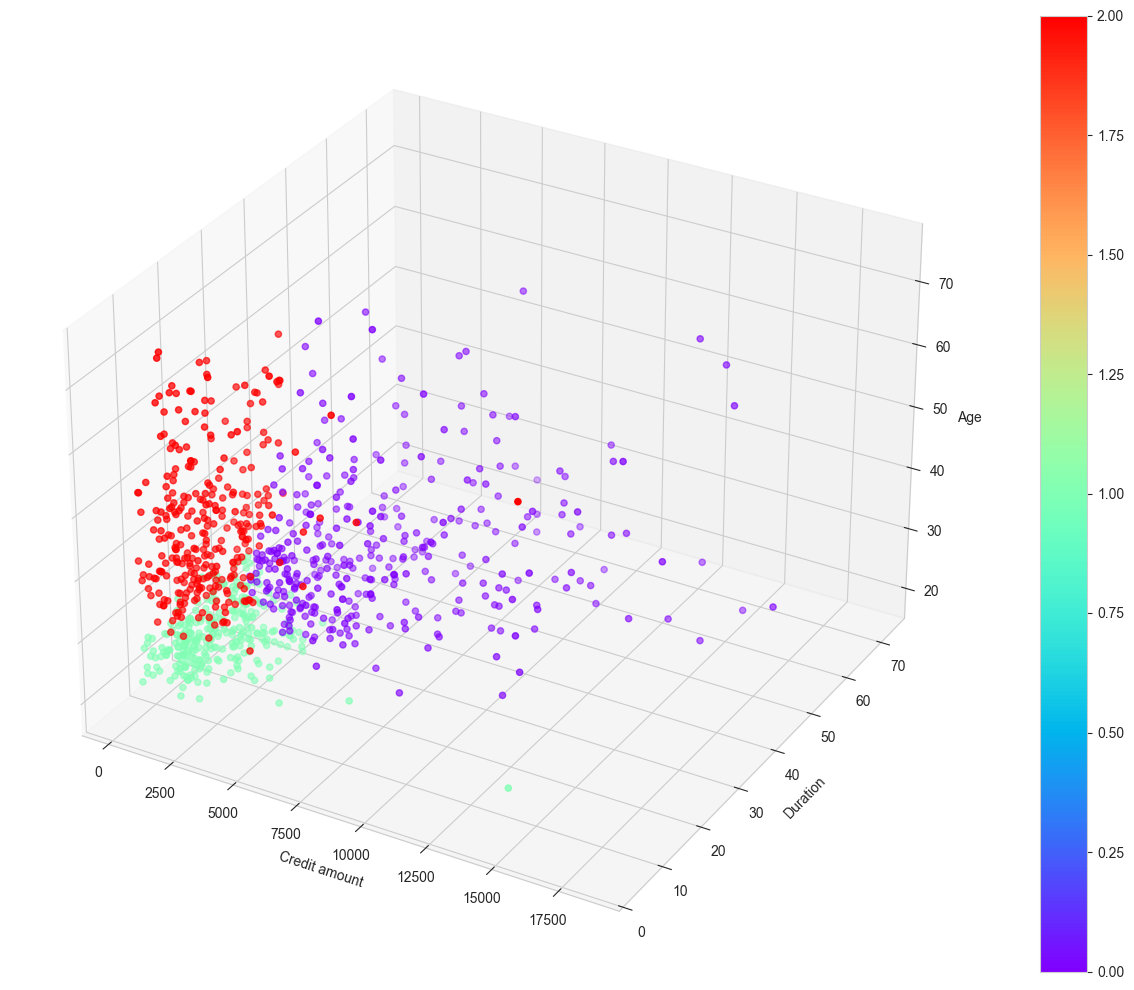

In [19]:
_3d_data_plot(clustered_data,labels=final_kmeans.labels_)